In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
import joblib
import warnings
warnings.filterwarnings("ignore")  

sns.set_style('whitegrid')


Note: you may need to restart the kernel to use updated packages.


In [4]:
car_dataset = pd.read_csv('car_data.csv')

In [8]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [9]:
car_dataset.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
print('\nfuel type:')
print(car_dataset['Fuel_Type'].value_counts())
print('\nseller type:')
print(car_dataset['Seller_Type'].value_counts())
print('\ntransmission:')
print(car_dataset['Transmission'].value_counts())
print('\nowner:')
print(car_dataset['Owner'].value_counts())


fuel type:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

seller type:
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64

transmission:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

owner:
Owner
0    290
1     10
3      1
Name: count, dtype: int64


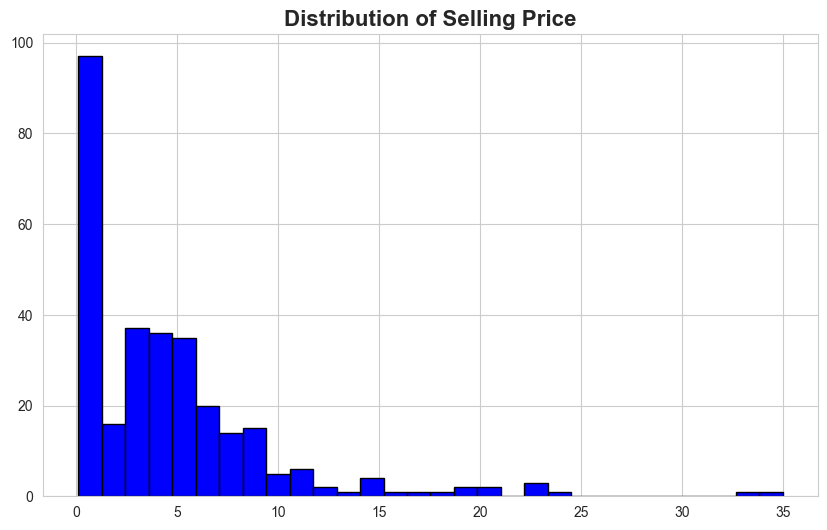

In [11]:
plt.figure(figsize=(10,6))
plt.hist(car_dataset['Selling_Price'], bins=30, color='blue', edgecolor='black')
plt.title('Distribution of Selling Price', fontsize=16, fontweight='bold')
plt.show()


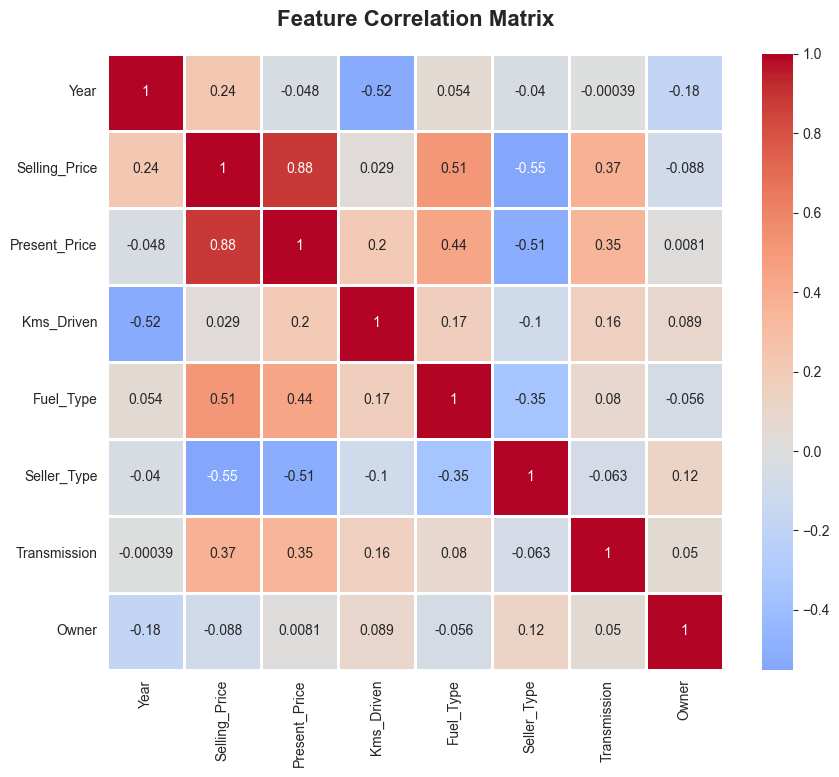

In [9]:
plt.figure(figsize=(10,8))
numeric_data = car_dataset.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=1, center=0, square=True)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.show()


Text(0, 0.5, 'Selling Price (Lakhs)')

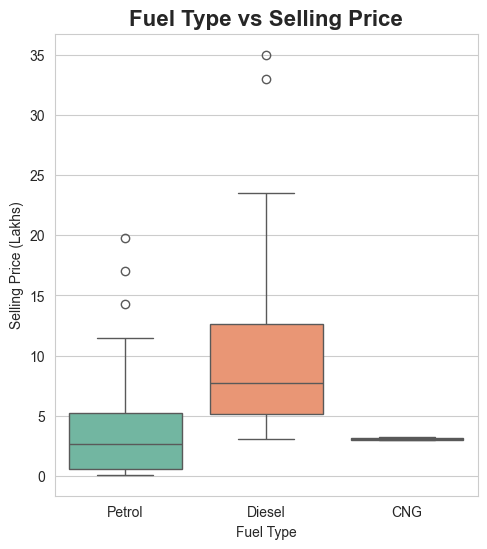

In [13]:
#Fuel Type vs Selling Price
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=car_dataset, palette='Set2')
plt.title('Fuel Type vs Selling Price', fontsize=16, fontweight='bold')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (Lakhs)')


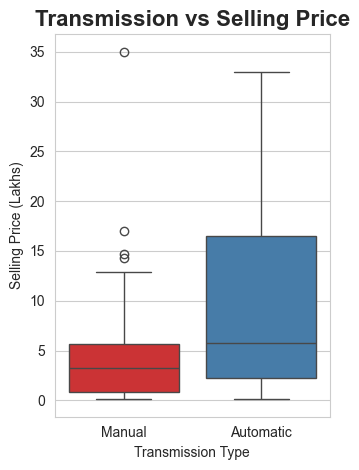

In [14]:
#Transmission vs Selling Price
plt.subplot(1, 2, 2)
sns.boxplot(x='Transmission', y='Selling_Price', data=car_dataset, palette='Set1')
plt.title('Transmission vs Selling Price', fontsize=16, fontweight='bold')
plt.xlabel('Transmission Type')
plt.ylabel('Selling Price (Lakhs)')
plt.tight_layout()
plt.show()


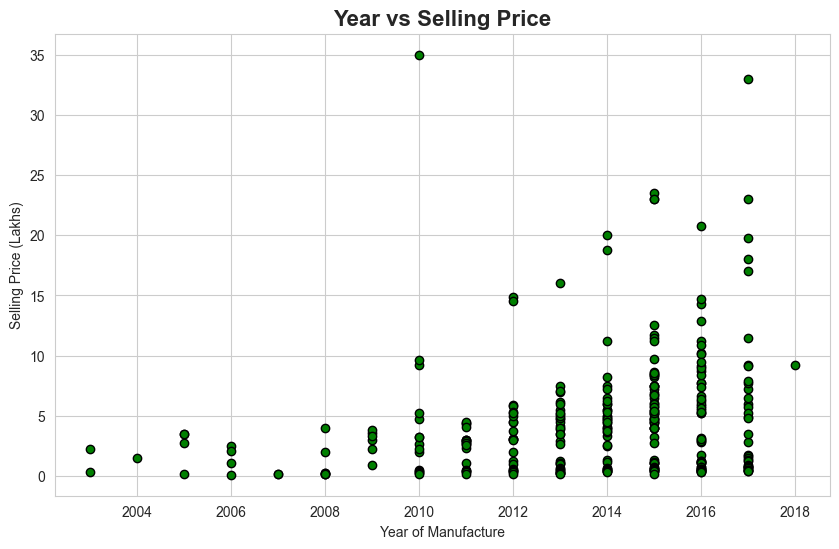

In [16]:
#year vs selling price
plt.figure(figsize=(10,6))
plt.scatter(car_dataset['Year'], car_dataset['Selling_Price'], color='green', edgecolor='black')
plt.title('Year vs Selling Price', fontsize=16, fontweight='bold')
plt.xlabel('Year of Manufacture')
plt.ylabel('Selling Price (Lakhs)')
plt.show()


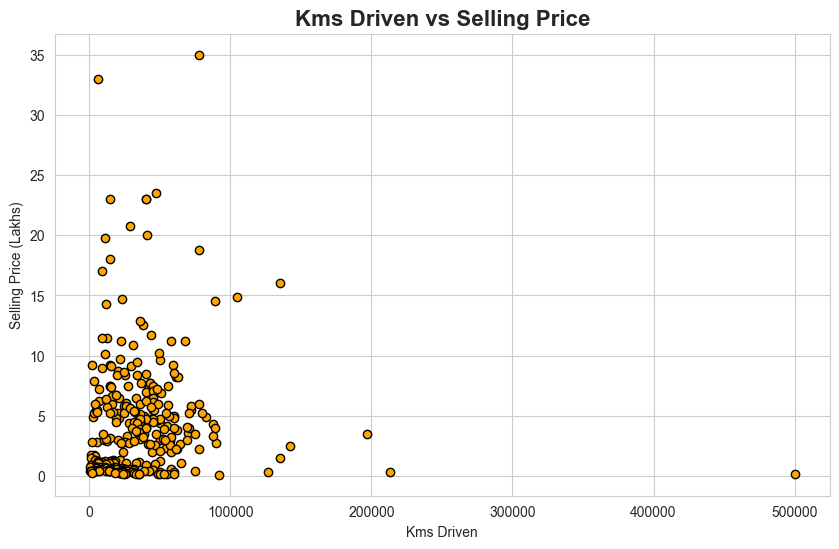

In [16]:
#kms driven vs selling price
plt.figure(figsize=(10,6))
plt.scatter(car_dataset['Kms_Driven'], car_dataset['Selling_Price'], color='orange', edgecolor='black')
plt.title('Kms Driven vs Selling Price', fontsize=16, fontweight='bold')    
plt.xlabel('Kms Driven')
plt.ylabel('Selling Price (Lakhs)')
plt.show()

In [5]:
#Encoding categorical data
car_dataset.replace({'Fuel_Type':{'Petrol':0, 'Diesel':1, 'CNG':2}}, inplace=True)
car_dataset.replace({'Seller_Type':{'Dealer':0, 'Individual':1}}, inplace=True)
car_dataset.replace({'Transmission':{'Manual':0, 'Automatic':1}}, inplace=True)
print('encoded dataset')
car_dataset.head()


encoded dataset


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [6]:
x = car_dataset.drop(['Car_Name', 'Selling_Price'], axis=1)


In [7]:
y = car_dataset['Selling_Price']
print(x.head)

<bound method NDFrame.head of      Year  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  Transmission  \
0    2014           5.59       27000          0            0             0   
1    2013           9.54       43000          1            0             0   
2    2017           9.85        6900          0            0             0   
3    2011           4.15        5200          0            0             0   
4    2014           6.87       42450          1            0             0   
..    ...            ...         ...        ...          ...           ...   
296  2016          11.60       33988          1            0             0   
297  2015           5.90       60000          0            0             0   
298  2009          11.00       87934          0            0             0   
299  2017          12.50        9000          1            0             0   
300  2016           5.90        5464          0            0             0   

     Owner  
0        0  
1      

In [20]:
print(y.head())

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f'Training sample: {x_train.shape[0]} (80%)')

Training sample: 240 (80%)


In [22]:
print(f'Testing sample: {x_test.shape[0]} (20%)')

Testing sample: 61 (20%)


In [10]:
#Training the model
#Model 1: Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

train_pred_lr = lin_reg.predict(x_train)
train_r2_lr = metrics.r2_score(y_train, train_pred_lr)
train_mae_lr = metrics.mean_absolute_error(y_train, train_pred_lr)
train_mse_lr = np.sqrt(metrics.mean_squared_error(y_train, train_pred_lr))

print('r2 score',train_r2_lr)
print('mae',train_mae_lr)
print('rmse',train_mse_lr)


r2 score 0.8839793496750801
mae 1.17610774962525
rmse 1.7513550543161647


In [11]:
test_pred_lr = lin_reg.predict(x_test)
test_r2_lr = metrics.r2_score(y_test, test_pred_lr)
test_mae_lr = metrics.mean_absolute_error(y_test, test_pred_lr)
test_mse_lr = np.sqrt(metrics.mean_squared_error(y_test, test_pred_lr))

print('r2 score',test_r2_lr)
print('mae',test_mae_lr)
print('rmse',test_mse_lr)

r2 score 0.8468053957654199
mae 1.2217615462341054
rmse 1.8785439185438502


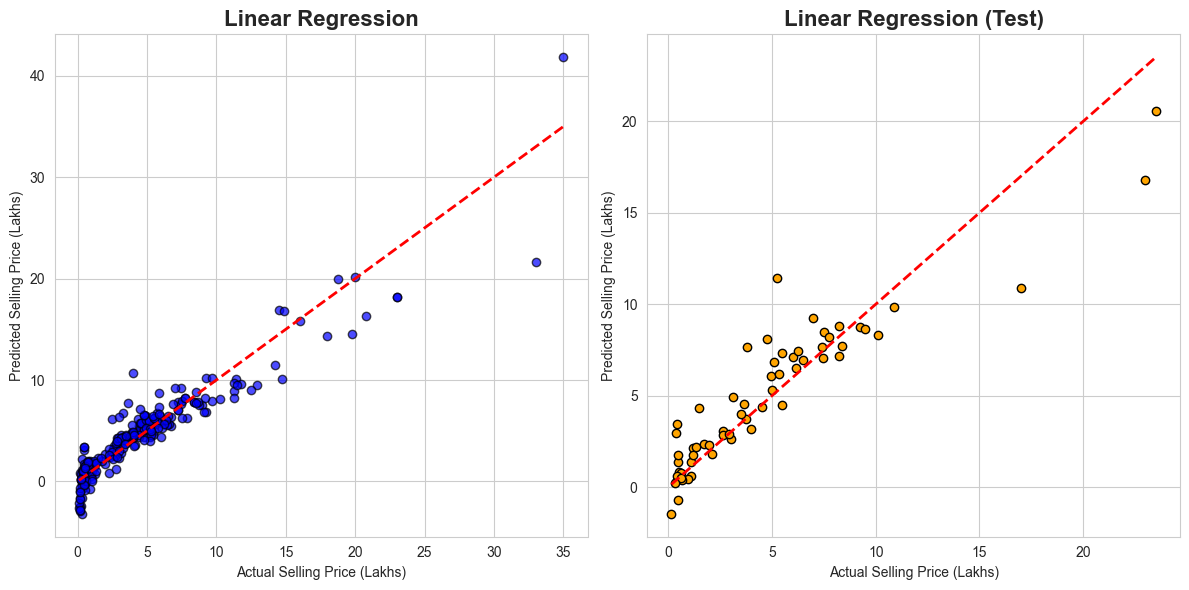

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(y_train, train_pred_lr, alpha=0.7, color='blue', edgecolor='black')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_title('Linear Regression', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Actual Selling Price (Lakhs)')
axes[0].set_ylabel('Predicted Selling Price (Lakhs)')

axes[1].scatter(y_test, test_pred_lr, color='orange', edgecolor='black')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Linear Regression (Test)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Actual Selling Price (Lakhs)')
axes[1].set_ylabel('Predicted Selling Price (Lakhs)')
plt.tight_layout()
plt.show()


In [13]:
#Model 2: Lasso Regression

from sklearn.linear_model import Lasso


lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(x_train, y_train)

train_pred_lasso = lasso_reg.predict(x_train)
train_r2_lasso = metrics.r2_score(y_train, train_pred_lasso)
train_mae_lasso = metrics.mean_absolute_error(y_train, train_pred_lasso)
train_rmse_lasso = np.sqrt(metrics.mean_squared_error(y_train, train_pred_lasso))

print('r2 score',train_r2_lasso)
print('mae',train_mae_lasso)
print('rmse',train_rmse_lasso)

r2 score 0.8726128074953646
mae 1.157733870551891
rmse 1.835140988551741


In [14]:
test_pred_lasso = lasso_reg.predict(x_test)
test_r2_lasso = metrics.r2_score(y_test, test_pred_lasso)
test_mae_lasso = metrics.mean_absolute_error(y_test, test_pred_lasso)
test_rmse_lasso = np.sqrt(metrics.mean_squared_error(y_test, test_pred_lasso))

print('r2 score',test_r2_lasso)
print('mae',test_mae_lasso)
print('rmse',test_rmse_lasso)

r2 score 0.8447749543056788
mae 1.2175561017342675
rmse 1.8909520511523952


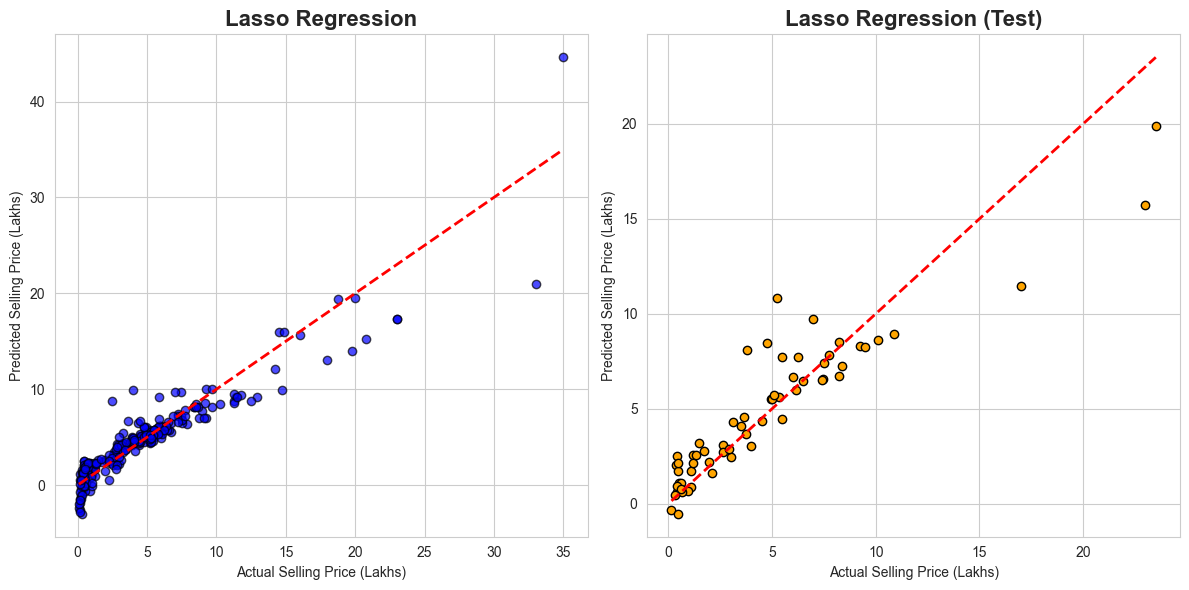

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(y_train, train_pred_lasso, alpha=0.7, color='blue', edgecolor='black')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_title('Lasso Regression', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Actual Selling Price (Lakhs)')
axes[0].set_ylabel('Predicted Selling Price (Lakhs)')

axes[1].scatter(y_test, test_pred_lasso, color='orange', edgecolor='black')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Lasso Regression (Test)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Actual Selling Price (Lakhs)')
axes[1].set_ylabel('Predicted Selling Price (Lakhs)')
plt.tight_layout()
plt.show()


In [17]:
#Model 3: Random Forest Regressor
# use n_jobs=-1 to utilize all cores, lowers memory footprint per tree
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(x_train, y_train)

train_pred_rf = rf_reg.predict(x_train)
train_r2_rf = metrics.r2_score(y_train, train_pred_rf)
train_mae_rf = metrics.mean_absolute_error(y_train, train_pred_rf)
train_rmse_rf = np.sqrt(metrics.mean_squared_error(y_train, train_pred_rf))     

print('r2 score',train_r2_rf)
print('mae',train_mae_rf)
print('rmse',train_rmse_rf)


r2 score 0.9840655518448314
mae 0.2623804166666664
rmse 0.6490453847446519


In [18]:
test_pred_rf = rf_reg.predict(x_test)
test_r2_rf = metrics.r2_score(y_test, test_pred_rf)
test_mae_rf = metrics.mean_absolute_error(y_test, test_pred_rf)
test_rmse_rf = np.sqrt(metrics.mean_squared_error(y_test, test_pred_rf))

print('r2 score', test_r2_rf)
print('mae', test_mae_rf)
print('rmse', test_rmse_rf)

r2 score 0.9625164143622483
mae 0.620155737704918
rmse 0.9292234957651291


In [19]:
feature_importances = pd.DataFrame({
'Feature': x.columns, 
'Importance': rf_reg.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feature_importances)

         Feature  Importance
1  Present_Price    0.879164
0           Year    0.063727
2     Kms_Driven    0.034059
5   Transmission    0.013077
3      Fuel_Type    0.006480
4    Seller_Type    0.002461
6          Owner    0.001032


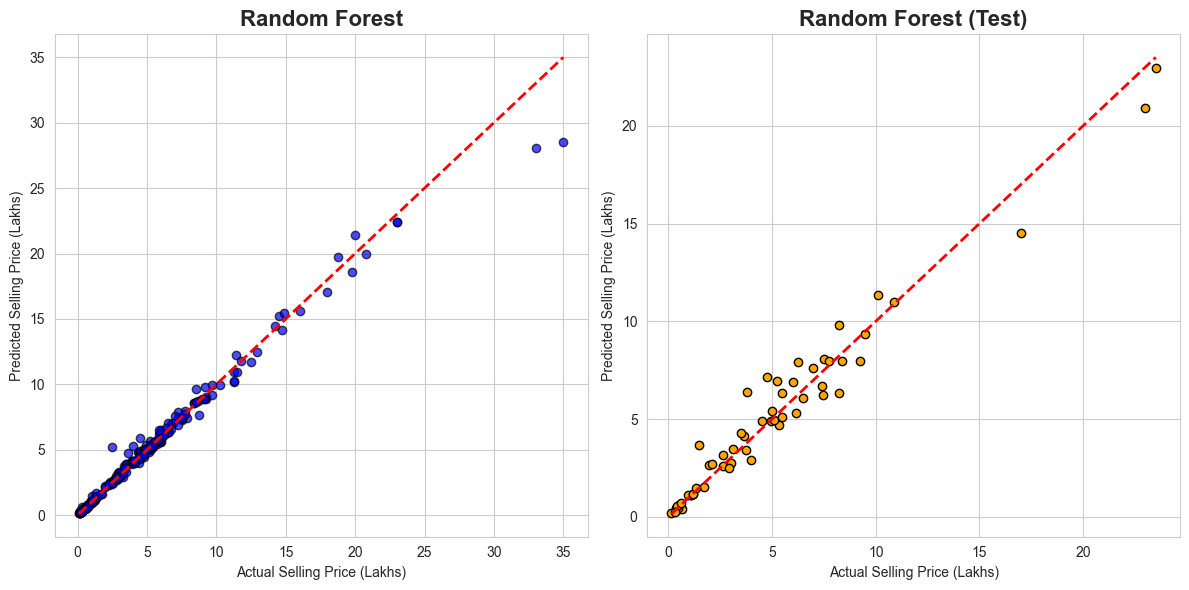

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(y_train, train_pred_rf, alpha=0.7, color='blue', edgecolor='black')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_title('Random Forest', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Actual Selling Price (Lakhs)')
axes[0].set_ylabel('Predicted Selling Price (Lakhs)')

axes[1].scatter(y_test, test_pred_rf, color='orange', edgecolor='black')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Random Forest (Test)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Actual Selling Price (Lakhs)')
axes[1].set_ylabel('Predicted Selling Price (Lakhs)')
plt.tight_layout()
plt.show()


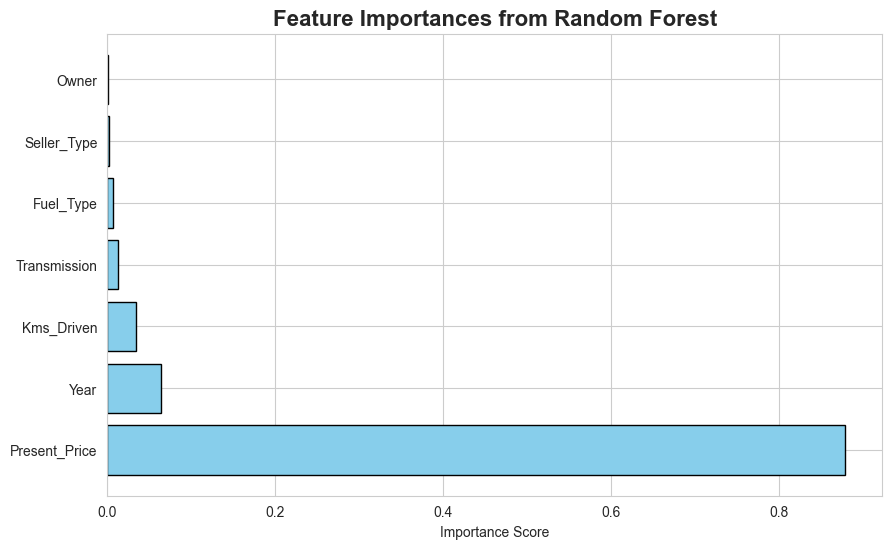

In [21]:
plt.figure(figsize=(10,6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Feature Importances from Random Forest', fontsize=16, fontweight='bold')
plt.show()


In [23]:
#Model Comparison

print('Linear Regression', test_r2_lr)
print('Random Forest', test_r2_rf)
print('Lasso Regression', test_r2_lasso)

Linear Regression 0.8468053957654199
Random Forest 0.9625164143622483
Lasso Regression 0.8447749543056788


In [24]:
#Save Best Model
joblib.dump(rf_reg, 'car_prediction_model.pkl')

['car_prediction_model.pkl']

In [26]:
input_data = pd.DataFrame({
    'Year': [2015],
    'Present_Price': [7.0],
    'Kms_Driven': [50000],
    'Fuel_Type': [0],  # Petrol
    'Seller_Type': [1],  # Individual
    'Transmission': [0],  # Manual
    'Owner': [1] 
})

prediction = rf_reg.predict(input_data)
print(f'Predicted Selling Price: {prediction[0]:.2f} Lakhs')


Predicted Selling Price: 4.34 Lakhs
